<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/utoencoder_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practical 9:** Generative Models - Building an Autoencoder

**Objective:** Explore generative modeling by reconstructing high-dimensional data.

**Dataset:** Fashion-MNIST

**Course Outcome:** CO5  
**Institution:** NIELIT ROPAR

---

This notebook will guide you step-by-step:
- Load and preprocess the Fashion-MNIST dataset
- Build a symmetrical Convolutional Autoencoder
- Train the model to compress and reconstruct images
- Visualize the fidelity loss

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


## Load and Preprocess Dataset

In [2]:
# We use Fashion-MNIST as it provides slightly more complex features than standard MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add channel dimension (required for convolutional layers)
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


## Build Symmetrical Autoencoder

In [3]:
def build_autoencoder():
    inputs = tf.keras.Input(shape=(28, 28, 1))

    # ENCODER: Compress the image into a lower-dimensional latent space
    x = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    x = tf.keras.layers.MaxPooling2D(2, padding='same')(x)
    x = tf.keras.layers.Conv2D(8, 3, activation='relu', padding='same')(x)
    encoded = tf.keras.layers.MaxPooling2D(2, padding='same')(x)

    # DECODER: Reconstruct the image from the latent space
    x = tf.keras.layers.Conv2D(8, 3, activation='relu', padding='same')(encoded)
    x = tf.keras.layers.UpSampling2D(2)(x)
    x = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.UpSampling2D(2)(x)
    # Use sigmoid activation for the final layer to output values between 0 and 1
    decoded = tf.keras.layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    model = tf.keras.Model(inputs, decoded)
    return model

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [4]:
# Binary crossentropy works well here since our normalized pixel values are treated as probabilities
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

## Train Model

In [5]:
# Notice that the target data is the same as the input data (x_train, x_train)
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 62s 254ms/step - loss: 0.3677 - val_loss: 0.2984
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 58s 247ms/step - loss: 0.2885 - val_loss: 0.2854
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 248ms/step - loss: 0.2806 - val_loss: 0.2805
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 244ms/step - loss: 0.2771 - val_loss: 0.2782
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 84s 255ms/step - loss: 0.2752 - val_loss: 0.2764
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 252ms/step - loss: 0.2737 - val_loss: 0.2752
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 84s 262ms/step - loss: 0.2726 - val_loss: 0.2742
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 80s 253ms/step - loss: 0.2715 - val_loss: 0.2731
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 61s 261ms/step - loss: 0.2706 - val_loss: 0.2724
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 256ms/step - loss: 0.2698 - val_loss: 0.2715


## Evaluate Loss of Fidelity

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


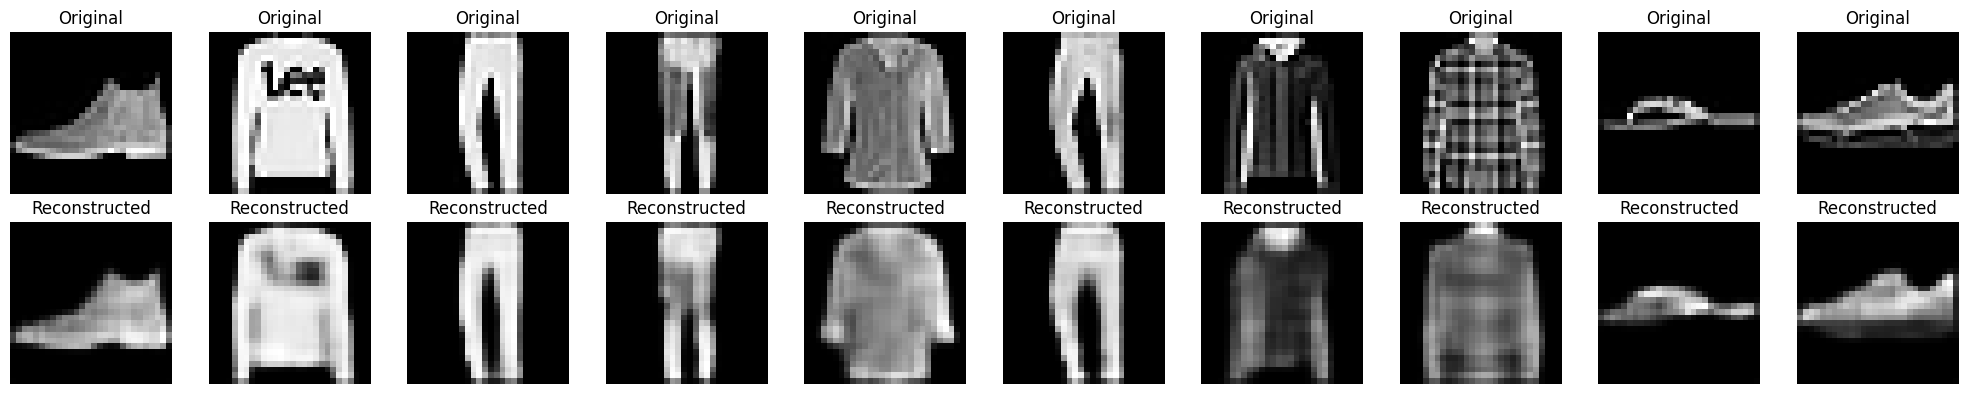

In [6]:
# Generate reconstructed images from the test set
decoded_imgs = autoencoder.predict(x_test)

# Visualize original vs reconstructed
n = 10  # Number of images to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(tf.squeeze(x_test[i]), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Display Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(tf.squeeze(decoded_imgs[i]), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()